In [740]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [741]:
path = r"C:\Users\HP\Desktop\AI_project\kc_house_data.csv"

df= pd.read_csv(path,usecols=['sqft_living','price'])

In [742]:
df.head()

,price,sqft_living
0,221900.0,1180
1,538000.0,2570
2,180000.0,770
3,604000.0,1960
4,510000.0,1680


In [743]:
df.shape

(21613, 2)

In [744]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   price        21613 non-null  float64
 1   sqft_living  21613 non-null  int64  
dtypes: float64(1), int64(1)
memory usage: 337.8 KB


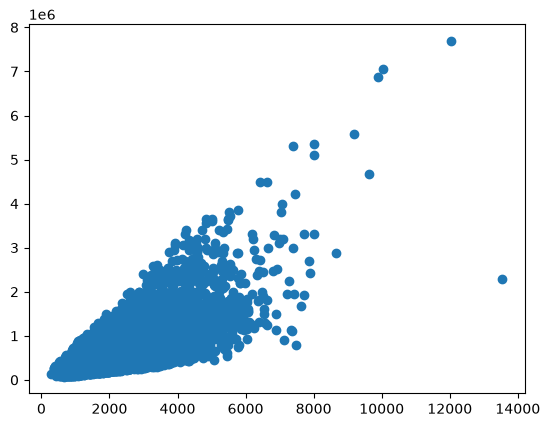

In [745]:
x = df['sqft_living'].values
y = df['price'].values
plt.scatter(x, y)

In [746]:
split = int(len(df) * 0.8)
split

17290

In [747]:


x_raw_train = df['sqft_living'].iloc[:split].values
x_raw_test = df['sqft_living'].iloc[split:].values
x_train = np.vstack([x_raw_train, x_raw_train ** 2]).T
x_test = np.vstack([x_raw_test, x_raw_test ** 2]).T

y_train = np.array(df['price'].iloc[:split])
y_test = np.array(df['price'].iloc[split:])

In [748]:
len(df) * 0.8

17290.4

In [749]:
x_train

array([[    1180,  1392400],
       [    2570,  6604900],
       [     770,   592900],
       ...,
       [    2540,  6451600],
       [    5150, 26522500],
       [    3420, 11696400]], shape=(17290, 2))

In [750]:
y_train

array([ 221900.,  538000.,  180000., ...,  775000., 2250000., 1350000.],
      shape=(17290,))

In [766]:
y_train = np.array(y_train).astype(float)
x_train = np.array(x_train).astype(float)
y_test = np.array(y_test).astype(float)
x_test = np.array(x_test).astype(float)


In [767]:
x_train[:3]


array([[0., 0.],
       [0., 0.],
       [0., 0.]])

In [768]:
x_train[0:3]


array([[0., 0.],
       [0., 0.],
       [0., 0.]])

In [769]:
def predict(x, w1, w2, b):
    y_hat = w1 * x[:, 0] + w2 * x[:, 1] + b
    return y_hat

In [770]:
w1 = 0.0
w2 = 0.0
b = 0.0
predict(x_train[0:3], w1, w2, b)

array([0., 0., 0.])

In [771]:
def cost(x, y, w1, w2, b):
    Y_hat = predict(x, w1, w2 , b)
    error = Y_hat - y
    c = np.sum(np.square(error)) / (2 * len(x))
    return c

In [772]:
x_train.shape

(17290, 2)

In [773]:
def gradient(x, y, w1, w2, b, alpha=0.001):
    Y_hat = predict(x, w1, w2, b)
    error = Y_hat - y
    gw1 = np.mean(error * x[:, 0])
    gw2 = np.mean(error * x[:, 1])
    gb = np.mean(error)

    w1 = w1 - alpha * gw1
    w2 = w2 - alpha * gw2
    b = b - alpha * gb

    return w1, w2, b

In [774]:
w1 = np.random.rand()
w2 = np.random.rand()
b = np.random.rand()

In [775]:
print("w1: ", w1)
print("w2: ", w2)
print("b: ", b)


w1:  0.5012471172230413
w2:  0.3592926517668191
b:  0.5887236209020816


In [776]:
epochs = 1000

history = []
for i in range(1, epochs + 1):
    w1, w2, b = gradient(x_train, y_train, w1, w2, b)
    loss = cost(x_train, y_train, w1, w2, b)
    print(f"Epoch {i}: w1 = {round(w1, 4)}, w2 = {round(w2, 4)}, b = {round(b, 4)}, loss = {round(loss, 4)}")
    history.append(loss)



Epoch 1: w1 = 0.6331, w2 = 0.4912, b = 533.8356, loss = 208842600680.6173
Epoch 2: w1 = 0.765, w2 = 0.623, b = 1066.5493, loss = 208558958696.6696
Epoch 3: w1 = 0.8968, w2 = 0.7548, b = 1598.7302, loss = 208275883713.0108
Epoch 4: w1 = 1.0285, w2 = 0.8866, b = 2130.379, loss = 207993374596.2073
Epoch 5: w1 = 1.1603, w2 = 1.0183, b = 2661.4961, loss = 207711430215.0914
Epoch 6: w1 = 1.292, w2 = 1.15, b = 3192.0821, loss = 207430049440.7561
Epoch 7: w1 = 1.4237, w2 = 1.2817, b = 3722.1375, loss = 207149231146.5518
Epoch 8: w1 = 1.5553, w2 = 1.4134, b = 4251.6629, loss = 206868974208.0805
Epoch 9: w1 = 1.687, w2 = 1.545, b = 4780.6587, loss = 206589277503.1922
Epoch 10: w1 = 1.8185, w2 = 1.6766, b = 5309.1255, loss = 206310139911.98
Epoch 11: w1 = 1.9501, w2 = 1.8081, b = 5837.0639, loss = 206031560316.7754
Epoch 12: w1 = 2.0816, w2 = 1.9397, b = 6364.4743, loss = 205753537602.1446
Epoch 13: w1 = 2.2131, w2 = 2.0712, b = 6891.3574, loss = 205476070654.8833
Epoch 14: w1 = 2.3446, w2 = 2.20

In [779]:
max_of_x1 = x_train[:,0].max()
max_of_x2 = x_train[:,1].max()

In [780]:
x_train[:,0] = x_train[:,0] / max_of_x1
x_train[:,1] = x_train[:,1] / max_of_x2